In [20]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

In [21]:
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")

df = pd.read_csv(BASE_FILE)

print(df.shape)
df.head()

mapping = {
    # Orgovyx
    'orgovyx': 'Orgovyx',
    'orogovyx': 'Orgovyx',
    'orgovyx and nubeqa': 'Orgovyx',


    # Lupron
    'lupron': 'Lupron',
    'lupron depot': 'Lupron',
    'leupron': 'Lupron',
    'lupon': 'Lupron',
    'lpron': 'Lupron',

    # Bicalutamide / Casodex
    'bicalutamide': 'Bicalutamide',
    'casodex': 'Bicalutamide',

    # Firmagon
    'firmagon': 'Firmagon',

    # Multi / transitions / combos
    'firmagon to lupron': 'Lupron',
    'lupron + casodex to lupron': 'Lupron',
    'lupron, orgovyx (d/c)': 'Lupron',
    'firmagon to orgovyx': 'Orgovyx',
    'lupron, firmagon': 'Lupron',
    'bicalutamide + lupron': 'Lupron',
    'bicalutamide, then lupron': 'Lupron',
    'casodex to lpron': 'Lupron',
    'bicalutamide to lupron to orgovyx': 'Orgovyx',
    'lupron + bicalutamide': 'Lupron',
    'lupron to orgovyx': 'Orgovyx',
    'bicalutamide to lupron': 'Lupron',
    'casodex to lupron': 'Lupron',
    'casodex to firmagon': 'Firmagon'
}

# Apply mapping
df["adt_agent"] = df["adt_agent"].replace(mapping)

#fix other_lipid_prior, statin_prior, lipid_meds_post

count_cols = [
    'lipid_meds_post'
]

binary_1_yes = [
    'statin_prior', 'other_lipid_prior'
]

df[count_cols] = df[count_cols].where(
    df[count_cols].isna(),
    (df[count_cols] != 0).astype(int)
)

for col in binary_1_yes:
    df[col] = df[col].where(df[col].isna(), (df[col] == 1).astype(int))

(239, 60)


In [ ]:
# percentage of patients with baseline HLD

na_count = df["hx_hld"].isna().sum()
na_pct = na_count / len(df) * 100

print(f"Missing hx_hld: {na_count} ({na_pct:.1f}%) out of {len(df)} patients")

hld_rate = df["hx_hld"].mean() * 100  # works if 0/1 or bool
non_missing_n = df["hx_hld"].notna().sum()

print(f"Baseline HLD rate: {hld_rate:.1f}% ({df['hx_hld'].sum()}/{non_missing_n})")


Missing hx_hld: 36 (15.1%) out of 239 patients
Baseline HLD rate: 52.7% (107.0/203)


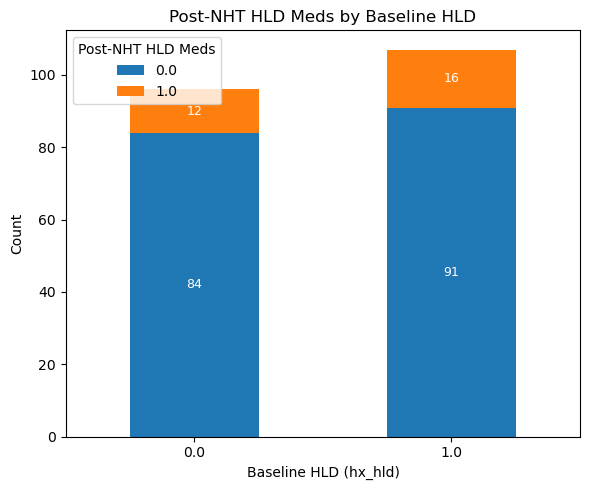

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["hx_hld"], df["lipid_meds_post"])

# plot
ax = ct.plot(kind="bar", stacked=True, figsize=(6,5))

# add count labels
for i, (idx, row) in enumerate(ct.iterrows()):
    bottom = 0
    for col in ct.columns:
        val = row[col]
        if val > 0:
            ax.text(i, bottom + val/2, str(val),
                    ha='center', va='center', fontsize=9, color='white')
        bottom += val

# labels
ax.set_title("Post-NHT HLD Meds by Baseline HLD")
ax.set_xlabel("Baseline HLD (hx_hld)")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.legend(title="Post-NHT HLD Meds")
plt.tight_layout()
plt.show()

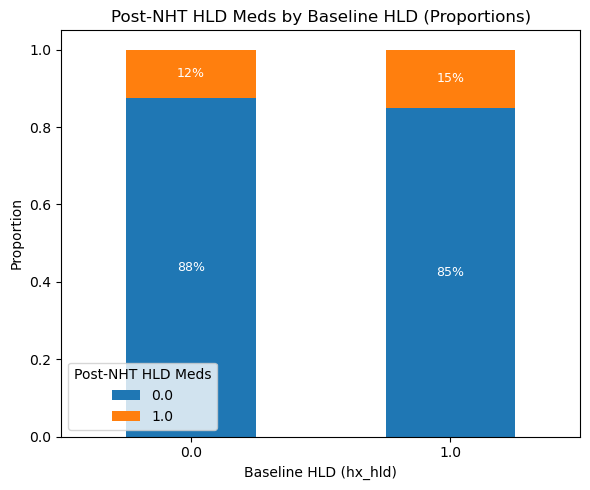

In [36]:
ct = pd.crosstab(df["hx_hld"], df["lipid_meds_post"], normalize="index")

ax = ct.plot(kind="bar", stacked=True, figsize=(6,5))

# % labels
for i, (idx, row) in enumerate(ct.iterrows()):
    bottom = 0
    for col in ct.columns:
        val = row[col]
        if val > 0:
            ax.text(i, bottom + val/2, f"{val:.0%}",
                    ha='center', va='center', fontsize=9, color='white')
        bottom += val

ax.set_title("Post-NHT HLD Meds by Baseline HLD (Proportions)")
ax.set_xlabel("Baseline HLD (hx_hld)")
ax.set_ylabel("Proportion")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.legend(title="Post-NHT HLD Meds")
plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import chi2_contingency

# contingency table
table = pd.crosstab(df["lipid_meds_post"], df["hx_hld"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("df:", dof)

print("\nExpected counts:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

Chi-square: 0.0913519762461058
p-value: 0.7624653827252152
df: 1

Expected counts:
hx_hld                 0.0        1.0
lipid_meds_post                      
0.0              82.758621  92.241379
1.0              13.241379  14.758621


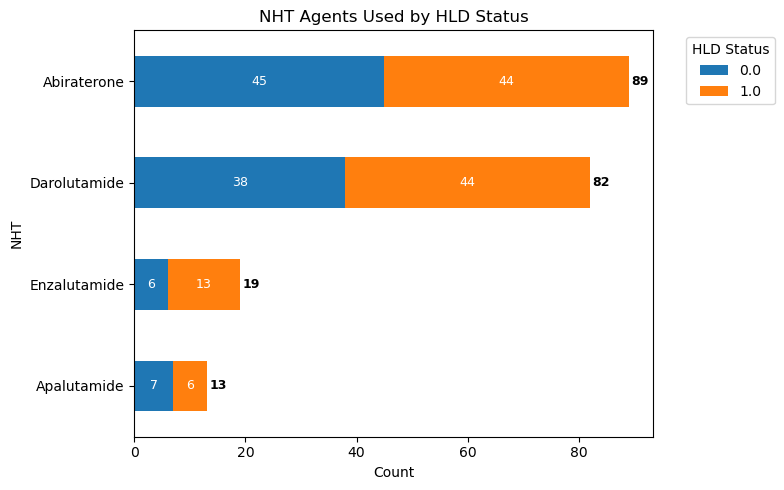

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["hx_hld"])

# reorder rows by TOTAL bar size (ascending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct.plot(kind="barh", stacked=True, figsize=(8,5))

# add segment labels
for i, (index, row) in enumerate(ct.iterrows()):
    left = 0
    for col in ct.columns:
        value = row[col]
        if value > 0:
            ax.text(left + value/2, i, str(value),
                    ha='center', va='center', fontsize=9, color='white')
        left += value

# (optional) add total at end of each bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + 0.5, i, str(total),
            va='center', fontsize=9, fontweight='bold')

# labels
ax.set_title("NHT Agents Used by HLD Status")
ax.set_ylabel("NHT")
ax.set_xlabel("Count")

plt.legend(title="HLD Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

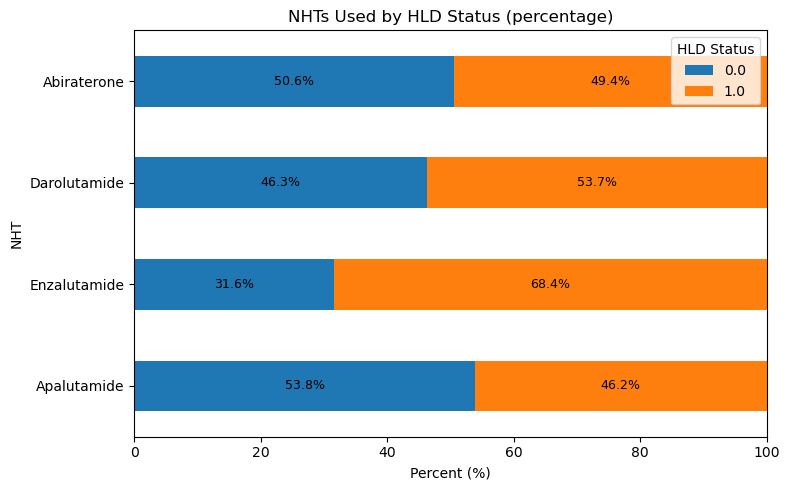

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["hx_hld"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=True).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("NHTs Used by HLD Status (percentage)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("NHT")

plt.legend(title="HLD Status")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

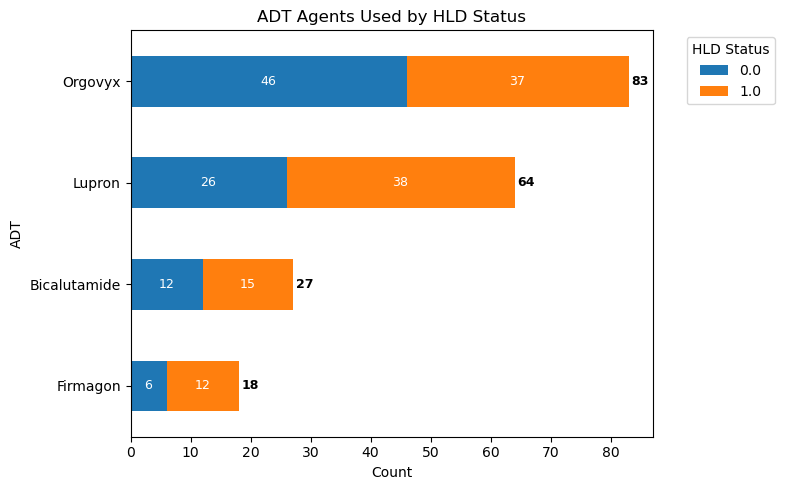

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["adt_agent"], df["hx_hld"])

# reorder rows by TOTAL bar size (ascending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct.plot(kind="barh", stacked=True, figsize=(8,5))

# add segment labels
for i, (index, row) in enumerate(ct.iterrows()):
    left = 0
    for col in ct.columns:
        value = row[col]
        if value > 0:
            ax.text(left + value/2, i, str(value),
                    ha='center', va='center', fontsize=9, color='white')
        left += value

# (optional) add total at end of each bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + 0.5, i, str(total),
            va='center', fontsize=9, fontweight='bold')

# labels
ax.set_title("ADT Agents Used by HLD Status")
ax.set_ylabel("ADT")
ax.set_xlabel("Count")

plt.legend(title="HLD Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

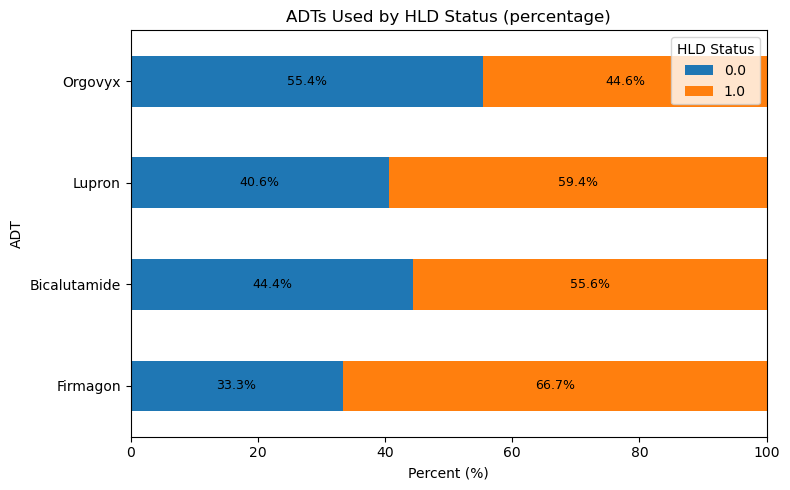

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["adt_agent"], df["hx_hld"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=True).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("ADTs Used by HLD Status (percentage)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("ADT")

plt.legend(title="HLD Status")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [64]:
import statsmodels.api as sm

df_model = df[["adt_agent", "hx_hld"]].dropna().copy()

y = df_model["adt_agent"].astype(str)

X = df_model[["hx_hld"]]
X = sm.add_constant(X)

model_adt = sm.MNLogit(y, X).fit()

print(model_adt.summary())

Optimization terminated successfully.
         Current function value: 1.213858
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:              adt_agent   No. Observations:                  192
Model:                        MNLogit   Df Residuals:                      186
Method:                           MLE   Df Model:                            3
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.01033
Time:                        22:02:27   Log-Likelihood:                -233.06
converged:                       True   LL-Null:                       -235.49
Covariance Type:            nonrobust   LLR p-value:                    0.1821
adt_agent=Firmagon       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.6931      0.500     -1.386      0.166      -1.673       0.287
hx_hl

In [61]:
import statsmodels.api as sm

df_model2 = df[["specific_nht_used", "hx_hld"]].dropna().copy()

y = df_model2["specific_nht_used"].astype(str)

X = df_model2[["hx_hld"]]
X = sm.add_constant(X)

model_adt = sm.MNLogit(y, X).fit()

print(model_adt.summary())

Optimization terminated successfully.
         Current function value: 1.119047
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:      specific_nht_used   No. Observations:                  203
Model:                        MNLogit   Df Residuals:                      197
Method:                           MLE   Df Model:                            3
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                0.005629
Time:                        22:00:28   Log-Likelihood:                -227.17
converged:                       True   LL-Null:                       -228.45
Covariance Type:            nonrobust   LLR p-value:                    0.4624
 specific_nht_used=Apalutamide       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.8608      0.406     -4.580     

In [65]:
import statsmodels.formula.api as smf

df_model = df[["lipid_meds_post", "statin_prior", "other_lipid_prior"]].dropna().copy()

model = smf.logit(
    "lipid_meds_post ~ statin_prior + other_lipid_prior",
    data=df_model
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.398908
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        lipid_meds_post   No. Observations:                  203
Model:                          Logit   Df Residuals:                      200
Method:                           MLE   Df Model:                            2
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                0.005687
Time:                        22:09:36   Log-Likelihood:                -80.978
converged:                       True   LL-Null:                       -81.442
Covariance Type:            nonrobust   LLR p-value:                    0.6293
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.6747      0.291     -5.752      0.000      -2.245      -1.104
statin_p